### Import libraries

In [ ]:
#from preprocess import text_preprocess

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

[nltk_data] Downloading package punkt to /home/kayran/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/kayran/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/kayran/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Cargue y limpieza del dataset
En las celdas siguientes estarán la **preparación de los datos** de los datos tanto la justificaciones sobre cada decisión.

In [2]:
path = "Data.xlsx"

xls = pd.ExcelFile(path)
print("Hojas:", xls.sheet_names)

df = pd.read_excel(path, "Sheet1")

#df = df.head(1000)

print(df.shape)
display(df.head())
display(df.columns)

Hojas: ['Sheet1']
(9656, 2)


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


Index(['textos', 'ODS'], dtype='object')

In [3]:
TEXT_COL = "textos"
LABEL_COL = "ODS"

df = df[[TEXT_COL, LABEL_COL]].dropna()
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df.drop_duplicates(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)

print(df.shape)
print(df[LABEL_COL].value_counts().sort_index())

(9656, 2)
ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["textos"], df["ODS"],
    test_size=0.2,
    random_state=42,
    stratify=df["ODS"]
)

Se utilizó stratify= con la columna ODS durante la división del dataset para mantener la misma proporción de clases (ODS) en los conjuntos de entrenamiento y prueba, garantizando una evaluación más representativa del dataset.

In [ ]:

spanish_stopwords = set(stopwords.words('spanish'))
stemmer = SnowballStemmer("spanish")
tokenizer = RegexpTokenizer(r'\w+')

def text_preprocess(text):
    
    tokens = tokenizer.tokenize(text.lower())
    tokens = [word for word in tokens if word not in spanish_stopwords]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)


<>:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
/tmp/ipykernel_7638/3626972437.py:4: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  tokenizer = RegexpTokenizer(r'\w+')


### Proceso de limpieza y preprocesamiento
* Para mejorar la eficiencia del procesamiento se definieron las stopwords fuera de la función de preprocesamiento, evitando su carga repetida durante la vectorización de los textos.

* Se aplicó un proceso de preprocesamiento de texto que incluye tokenización mediante expresiones regulares, utilizando RegexpTokenizer(r'\w+'), el cual nos permite separar el texto en palabras eliminando signos de puntuación. Luego se realizó la eliminación de palabras frecuentes del idioma español con stopwords, como "y" "de" y otras preposiciones,para quitar palabras que aportan poco significado para la clasificación. Finalmente, se aplicó una reducción morfológica mediante stemming con SnowballStemmer, el cual tiene la opcion para trabajar con la semantica del español. Este proceso permite normalizar los textos y reducir la variabilidad de las palabras antes de vectorizarlas finalmente.

**Nota:**
Inicialmente el proceso de limpieza y preprocesamiento de los textos se encontraba definido directamente dentro del notebook. Sin embargo, al momento de integrar el modelo en la aplicación desarrollada con Streamlit se presentaron errores asociados a la carga del modelo y al reconocimiento de la función de preprocesamiento.

Para solucionar este inconveniente y garantizar que el mismo procedimiento de transformación de texto se utilice tanto en el entrenamiento del modelo como en su despliegue, se decidió mover la función `text_preprocess` a un archivo externo (`preprocess.py`). De esta forma, la función puede ser importada tanto en el notebook como en la aplicación de Streamlit, asegurando consistencia en el pipeline y evitando problemas al cargar el modelo serializado.

La versión original del código se dejó en el notebook con el fin de mantener la referencia a las transformaciones de texto realizadas durante el desarrollo del proyecto.


### Pipeline
Se creará el **pipeline** después de dejar listos los datos

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
   #Paso 1
    ("tfidf", TfidfVectorizer(preprocessor=text_preprocess)),
   #Paso 2
    ("svd", TruncatedSVD()),
   #Paso 3
    ("clf", LogisticRegression())
])

### Justificaciones
* **Paso 1**: 
Antes de aplicar la vectorización, cada texto es procesado mediante la función text_preprocess, en la cual se realiza el preprocesamiento necesario del lenguaje natural. Este proceso incluye tokenización, eliminación de stopwords en español y reducción morfológica mediante stemming, con el objetivo de eliminar todo ese ruido linguístico y normalizar las palabras. De esta forma, el vectorizador TF-IDF aplica sobre textos más limpios y representativos, lo que mejora la calidad de la representación numérica utilizada por el modelo.

* **Paso 2**: Después de aplicar TF-IDF, los textos quedan representados por vectores con miles de características. Para reducir esta alta dimensionalidad utilizamos TruncatedSVD, una técnica de reducción dimensional que funciona para matrices dispersas que son las que genera el  TF-IDF lo que permite un procesamiento mas eficiente y que usa menos recursos.

* **Paso 3**: En esta etapa se utiliza Regresión Logística como algoritmo de clasificación. Este modelo lo consideramos adecuado para problemas de clasificación de texto porque funciona bien en espacios de alta dimensionalidad vectores generados por TF-IDF y permite estimar la probabilidad de que un documento pertenezca a cada ODS.

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "svd__n_components": [100, 200, 300],
    "clf__C": [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro"
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'svd__n_components': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

Definimos el grid para la búsqueda de hiperparámetros dentro del modelo de clasificación, principalmente la cantidad de componentes a la que buscamos reducir las dimensiones del texto preprocesado (SVD components) y el parámetro C de la regresion logistica, que controla la regularización del modelo.

Ejecutamos GridSearchCV para realizar la búsqueda de hiperparámetros utilizando f1_macro que sirve para clasificacion multiclase como métrica principal, ya que equilibra precision y recall, permitiendo evaluar el desempeño del modelo de forma más balanceada en este problema.

In [8]:
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)

print("\nMejor score en validación cruzada:")
print(grid.best_score_)

mejor_modelo = grid.best_estimator_

Mejores hiperparámetros encontrados:
{'clf__C': 10, 'svd__n_components': 300}

Mejor score en validación cruzada:
0.8457375148597036


In [9]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('svd', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function tex...x7fb5e2c6dfe0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


#### Evidencia de desempeño
En las celdas siguientes podemos ver cuál es el desempeño del modelo, se agregó matriz de confusión para identificar tipos de ODS que confunde.

**Predicción**

In [10]:
y_pred = mejor_modelo.predict(X_test)

**Métricas**

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8721532091097308

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.84      0.80      0.82       101
           2       0.77      0.82      0.80        74
           3       0.90      0.93      0.92       179
           4       0.95      0.98      0.96       205
           5       0.92      0.94      0.93       214
           6       0.92      0.88      0.90       139
           7       0.90      0.88      0.89       158
           8       0.60      0.61      0.60        89
           9       0.73      0.77      0.75        69
          10       0.71      0.60      0.65        70
          11       0.82      0.84      0.83       122
          12       0.84      0.82      0.83        62
          13       0.85      0.85      0.85        93
          14       0.91      0.91      0.91        75
          15       0.95      0.88      0.91        66
          16       0.94      0.95      0.95       216

    accuracy            

* El modelo obtuvo una exactitud (accuracy) de 0.87 sobre el conjunto de prueba, lo que indica que aproximadamente el 87% de los textos fueron clasificados correctamente en su respectivo Objetivo de Desarrollo Sostenible.

* El F1-score macro fue de 0.84, lo cual representa un buen desempeño considerando que el problema corresponde a una clasificación multiclase con más de quince categorías. Esta métrica es particularmente relevante ya que promedia el rendimiento entre todas las clases sin favorecer aquellas con mayor número de ejemplos.

* Se observa que algunos ODS presentan un desempeño superior, como los relacionados con educación, salud e instituciones, posiblemente debido a que poseen vocabulario más distintivo dentro del corpus textual. En contraste, ciertos objetivos asociados a aspectos económicos presentan mayor dificultad de clasificación debido a la similitud semántica entre sus textos.

**Matriz de confusión**

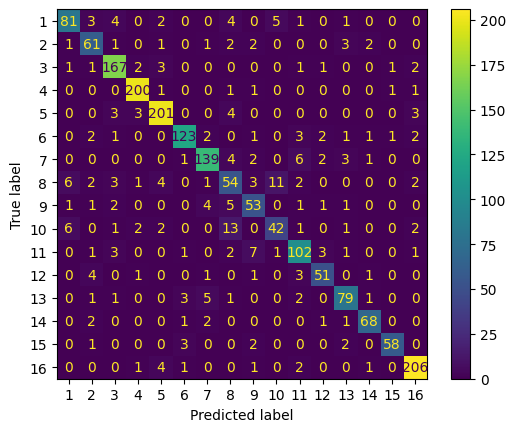

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

* La matriz de confusión permite observar el desempeño del modelo para cada uno de los Objetivos de Desarrollo Sostenible. Se aprecia que la mayoría de las predicciones correctas se concentran en la diagonal principal, lo que indica que el modelo logra identificar adecuadamente los textos correspondientes a cada ODS.

* Algunas clases presentan un desempeño particularmente alto, como los ODS relacionados con educación, igualdad de género e instituciones, lo cual puede explicarse por la presencia de vocabulario más distintivo en los textos asociados a estos objetivos.

* En contraste, ciertos objetivos relacionados con aspectos económicos muestran mayor confusión entre sí, debido a la similitud semántica entre los términos utilizados en sus descripciones. Aun así, el modelo logra un desempeño global adecuado para el problema de clasificación planteado.

* El F1-score macro de 0.84 muestra que el modelo mantiene un desempeño balanceado entre las diferentes clases, incluso cuando algunas tienen menos ejemplos.

* Algunas clases presentan menor desempeño, lo cual puede deberse a similitudes semánticas entre ciertos ODS o a una menor cantidad de ejemplos disponibles para su entrenamiento.

**Ejemplos de predicción**

In [13]:
import random

indices = random.sample(range(len(X_test)), 4)

for i in indices:
    print("Texto:", X_test.iloc[i])
    print("ODS real:", y_test.iloc[i])
    print("ODS predicho:", y_pred[i])
    print("-----")

Texto: Los estados débiles del África subsahariana utilizan el derecho internacional y sus instituciones para legitimar sus acciones y deslegitimar a sus enemigos internos. En este ensayo, sostengo que durante los conflictos armados internos, los estados africanos utilizan el derecho penal internacional para redefinir el conflicto como internacional y, por lo tanto, recalificar a los opositores políticos nacionales como criminales/enemigos internacionales que son una amenaza para toda la comunidad. Esto, a su vez, prepara el escenario para invocar los privilegios beligerantes en virtud del derecho internacional humanitario (DIH).
ODS real: 16
ODS predicho: 16
-----
Texto: El derecho a la intimidad, al ser un derecho civil y político, pertenece a la primera generación de derechos humanos y su importancia no puede menoscabarse en ningún sentido. El Consejo de Europa adoptó en 1950 el Convenio Europeo de Derechos Humanos (CEDH) para la promoción de la democracia, el Estado de Derecho, los

* Se presentan algunos ejemplos de predicciones realizadas por el modelo sobre textos del conjunto de prueba. En varios casos el modelo logra identificar correctamente el Objetivo de Desarrollo Sostenible correspondiente, particularmente cuando el texto contiene vocabulario claramente asociado a un objetivo específico, como en los casos de igualdad de género o seguridad alimentaria.

* En algunos ejemplos el modelo presenta confusión entre objetivos relacionados temáticamente. Por ejemplo, los textos relacionados con gestión de residuos pueden asociarse tanto al ODS 11 como al ODS 12, lo cual explica ciertas predicciones incorrectas. Este comportamiento es esperable dado que algunos ODS comparten contextos semánticos similares.

### Exportar modelo
Se va a exportar el modelo para posteriorme usarlo en **Streamlit**

In [14]:
import joblib

joblib.dump(mejor_modelo, "modelo_ods.pkl")

['modelo_ods.pkl']

Link STREAMLIT: https://odsclassifier-haykvpewtyym5yuzjj7hus.streamlit.app/